# benchmark_retrieval_non_supervise.ipynb

In [3]:
# notebooks/benchmark_retrieval_non_supervise.ipynb
# ─────────────────────────────────────────────────────────────
# CELLULE 1 — Setup
# ─────────────────────────────────────────────────────────────

import sys
from pathlib import Path
import warnings
import time
warnings.filterwarnings("ignore")

RACINE = Path("..").resolve()
if str(RACINE) not in sys.path:
    sys.path.insert(0, str(RACINE))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bases de données
from elasticsearch import Elasticsearch
import psycopg2

# ML non supervisé
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer

# Métriques
from sklearn.metrics import precision_score, recall_score, f1_score

from dotenv import load_dotenv
import os

load_dotenv(RACINE / ".env")

# Installation si nécessaire
# pip install rank-bm25 sentence-transformers

print("Imports OK")

Imports OK


In [4]:
# ─────────────────────────────────────────────────────────────
# CELLULE 2 — Connexions
# ─────────────────────────────────────────────────────────────

es = Elasticsearch(
    f"http://{os.getenv('ELASTIC_HOST', 'localhost')}:"
    f"{os.getenv('ELASTIC_PORT', 9200)}"
)
assert es.ping(), "Elasticsearch inaccessible"
print(f"ES connecté — {es.count(index='offres')['count']} documents")

conn = psycopg2.connect(
    host     = os.getenv("POSTGRES_HOST", "localhost"),
    port     = int(os.getenv("POSTGRES_PORT", 5432)),
    dbname   = os.getenv("POSTGRES_DB", "job_market"),
    user     = os.getenv("POSTGRES_USER"),
    password = os.getenv("POSTGRES_PASSWORD"),
)
print("PostgreSQL connecté")

ES connecté — 9079 documents
PostgreSQL connecté


In [5]:
# ─────────────────────────────────────────────────────────────
# CELLULE 3 — Chargement des données
# ─────────────────────────────────────────────────────────────

# Offres complètes pour les moteurs de recherche
df_offres = pd.read_sql("""
    SELECT
        o.id,
        o.titre,
        o.description,
        o.localisation_ville,
        o.type_contrat,
        STRING_AGG(DISTINCT c.competence, ' ') AS competences
    FROM offres o
    LEFT JOIN competences c ON c.offre_id = o.id
    GROUP BY
        o.id, o.titre, o.description,
        o.localisation_ville, o.type_contrat
""", conn)

df_offres["texte"] = (
    df_offres["titre"].fillna("")       + " " +
    df_offres["titre"].fillna("")       + " " +
    df_offres["description"].fillna("") + " " +
    df_offres["competences"].fillna("")
)

# Ground truth — labels pour l'évaluation a posteriori
df_labels = pd.read_sql("""
    SELECT offre_id AS id, ml_keyword
    FROM ml_labels
""", conn)

# Keywords disponibles pour l'évaluation
keywords = df_labels["ml_keyword"].unique().tolist()

print(f"Offres chargées   : {len(df_offres)}")
print(f"Labels disponibles: {len(df_labels)}")
print(f"Keywords          : {len(keywords)}")
print(f"\nKeywords :\n{df_labels['ml_keyword'].value_counts().to_string()}")

Offres chargées   : 8592
Labels disponibles: 15048
Keywords          : 47

Keywords :
ml_keyword
data engineer                 600
business analyst              600
data manager                  600
ingénieur cloud               600
développeur fullstack         600
administrateur système        600
chef de projet                600
comptable                     600
responsable marketing         600
commercial                    600
chargé de communication       600
directeur financier           600
infirmier                     600
ingénieur data                571
pipeline données              571
data analyst                  483
ingénieur machine learning    410
ingénieur données             367
data scientist                329
scrum master                  269
devops engineer               260
UX designer                   257
business intelligence         252
architecte solution           248
product manager               248
architecte data               235
architecte données 

In [6]:
# ─────────────────────────────────────────────────────────────
# CELLULE 4 — Initialisation des moteurs de recherche
# ─────────────────────────────────────────────────────────────

print("Initialisation des moteurs...\n")

# ── TF-IDF ────────────────────────────────────────────────────
print("1/3 TF-IDF...")
debut = time.perf_counter()

tfidf         = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                sublinear_tf=True)
X_tfidf       = tfidf.fit_transform(df_offres["texte"])
temps_tfidf   = (time.perf_counter() - debut) * 1000

print(f"    Matrice TF-IDF : {X_tfidf.shape} — {temps_tfidf:.0f}ms")

# ── BM25 ──────────────────────────────────────────────────────
print("2/3 BM25...")
debut = time.perf_counter()

corpus_bm25   = [texte.lower().split() for texte in df_offres["texte"]]
bm25          = BM25Okapi(corpus_bm25)
temps_bm25    = (time.perf_counter() - debut) * 1000

print(f"    Index BM25 construit — {temps_bm25:.0f}ms")

# ── Sentence Transformers ──────────────────────────────────────
print("3/3 Sentence Transformers...")
print("    Chargement du modèle multilingue...")
debut = time.perf_counter()

# Modèle pré-entraîné multilingue — pas d'entraînement nécessaire
# Fonctionne en français et anglais
model_st      = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

print("    Calcul des embeddings (peut prendre quelques minutes)...")
embeddings_offres = model_st.encode(
    df_offres["texte"].tolist(),
    batch_size     = 64,
    show_progress_bar = True,
)
temps_st = (time.perf_counter() - debut) * 1000

print(f"    Embeddings : {embeddings_offres.shape} — {temps_st:.0f}ms")
print("\nTous les moteurs initialisés.")

Initialisation des moteurs...

1/3 TF-IDF...
    Matrice TF-IDF : (8592, 10000) — 7363ms
2/3 BM25...
    Index BM25 construit — 1847ms
3/3 Sentence Transformers...
    Chargement du modèle multilingue...


Loading weights: 100%|█| 199/199 [00:00<00:00, 


    Calcul des embeddings (peut prendre quelques minutes)...


Batches: 100%|█| 135/135 [25:19<00:00, 11.26s/i

    Embeddings : (8592, 768) — 1506082ms

Tous les moteurs initialisés.


In [17]:
# ─────────────────────────────────────────────────────────────
# CELLULE 5 — Fonctions de recherche
# ─────────────────────────────────────────────────────────────

def rechercher_tfidf(requete: str, top_k: int = 100) -> tuple:
    """Recherche TF-IDF + similarité cosinus."""
    debut      = time.perf_counter()
    x_requete  = tfidf.transform([requete])
    scores     = cosine_similarity(x_requete, X_tfidf).flatten()
    indices    = scores.argsort()[-top_k:][::-1]
    temps_ms   = (time.perf_counter() - debut) * 1000
    ids        = df_offres.iloc[indices]["id"].tolist()
    return ids, temps_ms


def rechercher_bm25(requete: str, top_k: int = 100) -> tuple:
    """Recherche BM25."""
    debut    = time.perf_counter()
    tokens   = requete.lower().split()
    scores   = bm25.get_scores(tokens)
    indices  = scores.argsort()[-top_k:][::-1]
    temps_ms = (time.perf_counter() - debut) * 1000
    ids      = df_offres.iloc[indices]["id"].tolist()
    return ids, temps_ms


def rechercher_sentence_transformers(requete: str, top_k: int = 100) -> tuple:
    """Recherche par similarité sémantique avec Sentence Transformers."""
    debut           = time.perf_counter()
    embedding_req   = model_st.encode([requete])
    scores          = cosine_similarity(embedding_req, embeddings_offres).flatten()
    indices         = scores.argsort()[-top_k:][::-1]
    temps_ms        = (time.perf_counter() - debut) * 1000
    ids             = df_offres.iloc[indices]["id"].tolist()
    return ids, temps_ms


def rechercher_elasticsearch(requete: str, top_k: int = 100) -> tuple:
    """Recherche Elasticsearch BM25 avec pondération des champs."""
    body = {
        "query": {
            "multi_match": {
                "query":  requete,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": top_k,
    }
    debut    = time.perf_counter()
    res      = es.search(index="offres", body=body)
    temps_ms = (time.perf_counter() - debut) * 1000
    ids      = [h["_id"] for h in res["hits"]["hits"]]
    return ids, temps_ms


# Dictionnaire des moteurs
MOTEURS = {
    "TF-IDF + Cosinus":       rechercher_tfidf,
    "BM25 (Python)":          rechercher_bm25,
    "Sentence Transformers":  rechercher_sentence_transformers,
    "Elasticsearch":          rechercher_elasticsearch,
}

print("Fonctions de recherche définies.")

Fonctions de recherche définies.


In [18]:
# ─────────────────────────────────────────────────────────────
# CELLULE 6 — Fonction d'évaluation commune
# ─────────────────────────────────────────────────────────────

def evaluer_moteur(
    fn_recherche,
    keyword:     str,
    df_labels:   pd.DataFrame,
    top_k:       int = 100,
) -> dict:
    """
    Évalue un moteur de recherche sur un keyword donné.

    Logique :
        - Lance la requête `keyword` dans le moteur
        - Vérifie si les résultats retournés ont ml_keyword == keyword
          dans le ground truth PostgreSQL
        - Calcule précision, rappel, F1

    ml_keyword sert uniquement à évaluer a posteriori —
    aucun moteur n'est entraîné avec cette information.
    """
    # IDs des offres positives dans le ground truth
    ids_positifs_gt = set(
        df_labels[df_labels["ml_keyword"] == keyword]["id"].values
    )

    if not ids_positifs_gt:
        return None

    # Recherche
    ids_retournes, temps_ms = fn_recherche(keyword, top_k=top_k)

    # IDs connus dans le ground truth
    ids_connus = set(df_labels["id"].values)

    # Offres retournées ET présentes dans le ground truth
    ids_evalues = [id_ for id_ in ids_retournes if id_ in ids_connus]

    # Construction y_true / y_pred
    # Offres retournées
    y_true_ret = [1 if id_ in ids_positifs_gt else 0 for id_ in ids_evalues]
    y_pred_ret = [1] * len(ids_evalues)

    # Faux négatifs — offres positives non retournées
    ids_retournes_set = set(ids_retournes)
    nb_fn             = len([
        id_ for id_ in ids_positifs_gt
        if id_ not in ids_retournes_set
    ])

    y_true = y_true_ret + [1] * nb_fn
    y_pred = y_pred_ret + [0] * nb_fn

    if not y_true:
        return None

    return {
        "keyword":        keyword,
        "precision":      round(precision_score(y_true, y_pred, zero_division=0), 4),
        "rappel":         round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1":             round(f1_score(y_true, y_pred, zero_division=0), 4),
        "temps_ms":       round(temps_ms, 3),
        "nb_positifs_gt": len(ids_positifs_gt),
        "nb_retournes":   len(ids_retournes),
        "vrais_positifs": int(sum(y_true_ret)),
        "faux_positifs":  int(len(y_true_ret) - sum(y_true_ret)),
        "faux_negatifs":  nb_fn,
    }

print("Fonction d'évaluation définie.")

Fonction d'évaluation définie.


In [19]:
# CORRECTION 2 — Aligner top_k sur la taille du ground truth

def evaluer_moteur_adaptatif(
    fn_recherche,
    keyword:   str,
    df_labels: pd.DataFrame,
) -> dict:
    """
    Version adaptative — top_k = nombre de positifs dans le ground truth.
    Évite de pénaliser le rappel artificiellement.
    """
    ids_positifs_gt = set(
        df_labels[df_labels["ml_keyword"] == keyword]["id"].values
    )
    if not ids_positifs_gt:
        return None

    # Adapter top_k à la taille du ground truth
    top_k = max(100, len(ids_positifs_gt))

    return evaluer_moteur(fn_recherche, keyword, df_labels, top_k=top_k)

In [20]:
# ─────────────────────────────────────────────────────────────
# CELLULE 7 — Benchmark complet
# ─────────────────────────────────────────────────────────────

resultats = []

for nom_moteur, fn_recherche in MOTEURS.items():
    print(f"\n=== {nom_moteur} ===")

    for keyword in keywords:
        res = evaluer_moteur_adaptatif(fn_recherche, keyword, df_labels)
        #res = evaluer_moteur(fn_recherche, keyword, df_labels, top_k=100)

        if res is None:
            print(f"  ⚠ '{keyword}' — aucun label disponible")
            continue

        resultats.append({"moteur": nom_moteur, **res})

        print(
            f"  '{keyword}' — "
            f"P={res['precision']:.3f} "
            f"R={res['rappel']:.3f} "
            f"F1={res['f1']:.3f} "
            f"({res['temps_ms']:.1f}ms)"
        )

df_resultats = pd.DataFrame(resultats)
print(f"\n{len(df_resultats)} évaluations effectuées.")


=== TF-IDF + Cosinus ===
  'data engineer' — P=0.578 R=0.578 F1=0.578 (71.3ms)
  'ingénieur données' — P=0.349 R=0.349 F1=0.349 (55.1ms)
  'ingénieur data' — P=0.503 R=0.503 F1=0.503 (55.7ms)
  'pipeline données' — P=0.235 R=0.235 F1=0.235 (52.9ms)
  'ETL développeur' — P=0.071 R=0.071 F1=0.071 (50.5ms)
  'architecte données' — P=0.391 R=0.391 F1=0.391 (54.8ms)
  'architecte data' — P=0.489 R=0.489 F1=0.489 (53.5ms)
  'MLOps' — P=0.171 R=0.171 F1=0.171 (55.5ms)
  'data scientist' — P=0.775 R=0.775 F1=0.775 (59.2ms)
  'machine learning engineer' — P=0.273 R=0.273 F1=0.273 (60.8ms)
  'ingénieur machine learning' — P=0.695 R=0.695 F1=0.695 (57.3ms)
  'NLP engineer' — P=0.525 R=0.525 F1=0.525 (55.4ms)
  'computer vision' — P=0.000 R=0.000 F1=0.000 (52.0ms)
  'data analyst' — P=0.727 R=0.727 F1=0.727 (54.6ms)
  'deep learning' — P=0.010 R=0.010 F1=0.010 (50.6ms)
  'analyste données' — P=0.298 R=0.298 F1=0.298 (52.0ms)
  'business analyst' — P=0.783 R=0.783 F1=0.783 (49.9ms)
  'business int

In [21]:
# ─────────────────────────────────────────────────────────────
# CELLULE 8 — Tableau récapitulatif
# ─────────────────────────────────────────────────────────────

resume = df_resultats.groupby("moteur").agg(
    precision_moy = ("precision", "mean"),
    rappel_moy    = ("rappel",    "mean"),
    f1_moy        = ("f1",        "mean"),
    temps_moy_ms  = ("temps_ms",  "mean"),
    temps_max_ms  = ("temps_ms",  "max"),
).round(4)

# Trier par F1 décroissant
resume = resume.sort_values("f1_moy", ascending=False)

print("\n=== TABLEAU RÉCAPITULATIF — Retrieval non supervisé ===\n")
print(resume.to_string())

# Identifier le meilleur moteur
meilleur = resume["f1_moy"].idxmax()
print(f"\n→ Meilleur moteur (F1) : {meilleur}")
print(f"  F1        : {resume.loc[meilleur, 'f1_moy']:.4f}")
print(f"  Précision : {resume.loc[meilleur, 'precision_moy']:.4f}")
print(f"  Rappel    : {resume.loc[meilleur, 'rappel_moy']:.4f}")
print(f"  Temps moy : {resume.loc[meilleur, 'temps_moy_ms']:.2f} ms")


=== TABLEAU RÉCAPITULATIF — Retrieval non supervisé ===

                       precision_moy  rappel_moy  f1_moy  temps_moy_ms  temps_max_ms
moteur                                                                              
TF-IDF + Cosinus              0.4265      0.4265  0.4265       53.2787        71.297
BM25 (Python)                 0.3845      0.3845  0.3845        7.3866        24.058
Elasticsearch                 0.3289      0.3246  0.3266       22.5172        96.731
Sentence Transformers         0.2768      0.2768  0.2768      129.5966       157.137

→ Meilleur moteur (F1) : TF-IDF + Cosinus
  F1        : 0.4265
  Précision : 0.4265
  Rappel    : 0.4265
  Temps moy : 53.28 ms


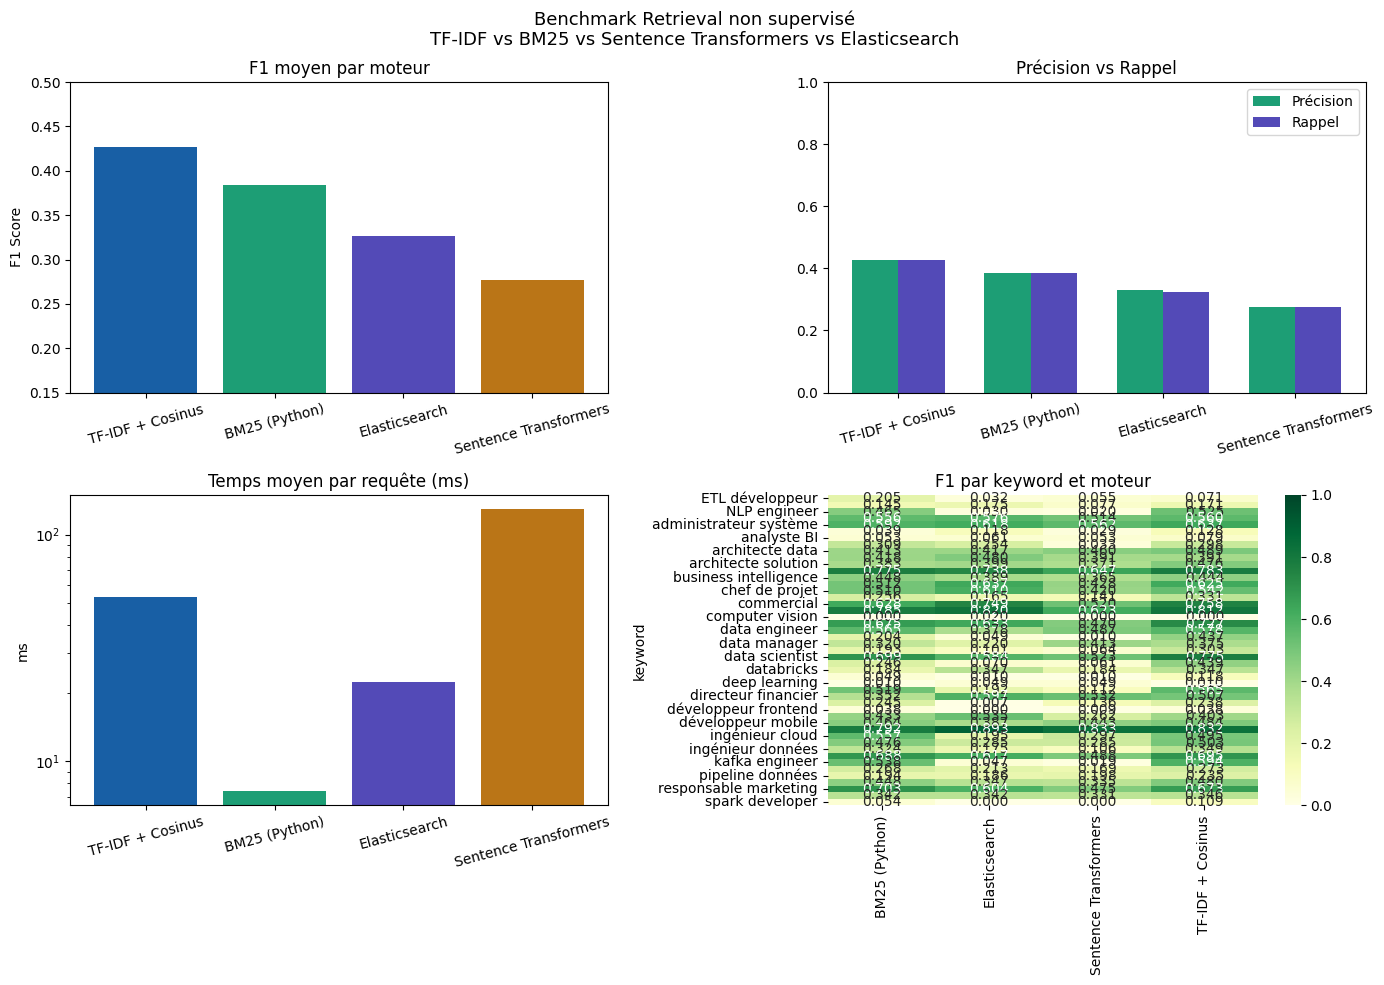

In [26]:
# ─────────────────────────────────────────────────────────────
# CELLULE 9 — Visualisations
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Benchmark Retrieval non supervisé\n"
    "TF-IDF vs BM25 vs Sentence Transformers vs Elasticsearch",
    fontsize=13
)

moteurs   = resume.index.tolist()
couleurs  = ["#185FA5", "#1D9E75", "#534AB7", "#BA7517"]

# ── F1 par moteur ─────────────────────────────────────────────
axes[0, 0].bar(moteurs, resume["f1_moy"], color=couleurs)
axes[0, 0].set_title("F1 moyen par moteur")
axes[0, 0].set_ylabel("F1 Score")
axes[0, 0].set_ylim(0.15, 0.5)
axes[0, 0].tick_params(axis="x", rotation=15)

# ── Précision / Rappel par moteur ─────────────────────────────
x = np.arange(len(moteurs))
w = 0.35
axes[0, 1].bar(x - w/2, resume["precision_moy"], w,
               label="Précision", color="#1D9E75")
axes[0, 1].bar(x + w/2, resume["rappel_moy"],    w,
               label="Rappel",    color="#534AB7")
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(moteurs, rotation=15)
axes[0, 1].set_title("Précision vs Rappel")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()

# ── Temps d'exécution ─────────────────────────────────────────
axes[1, 0].bar(moteurs, resume["temps_moy_ms"], color=couleurs)
axes[1, 0].set_title("Temps moyen par requête (ms)")
axes[1, 0].set_ylabel("ms")
axes[1, 0].set_yscale("log")
axes[1, 0].tick_params(axis="x", rotation=15)

# ── F1 par keyword et par moteur ──────────────────────────────
df_pivot = df_resultats.pivot_table(
    index   = "keyword",
    columns = "moteur",
    values  = "f1",
)
sns.heatmap(
    df_pivot,
    annot  = True,
    fmt    = ".3f",
    cmap   = "YlGn",
    ax     = axes[1, 1],
    vmin   = 0,
    vmax   = 1,
)
axes[1, 1].set_title("F1 par keyword et moteur")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.savefig("benchmark_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# ─────────────────────────────────────────────────────────────
# CELLULE 10 — Retrieve & Rerank
# ─────────────────────────────────────────────────────────────
"""
Architecture finale :
    1. ES récupère les top-50 candidats (vitesse)
    2. Sentence Transformers reclasse ces 50 candidats (précision)
"""

def retrieve_and_rerank(
    requete: str,
    top_k_es: int = 50,
    top_k_final: int = 10,
) -> tuple:
    """
    Retrieve & Rerank :
        1. ES récupère top_k_es candidats
        2. ST reclasse et retourne top_k_final
    """
    debut = time.perf_counter()

    # ── Étape 1 : Retrieve (ES) ───────────────────────────────
    body = {
        "query": {
            "multi_match": {
                "query":  requete,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": top_k_es,
        "_source": ["id", "titre", "description", "competences"]
    }
    res_es        = es.search(index="offres", body=body)
    ids_candidats = [h["_id"] for h in res_es["hits"]["hits"]]

    # ── Étape 2 : Rerank (Sentence Transformers) ──────────────
    # Récupérer les textes des candidats
    df_candidats  = df_offres[df_offres["id"].isin(ids_candidats)].copy()

    if df_candidats.empty:
        return [], (time.perf_counter() - debut) * 1000

    # Encoder la requête et les candidats
    emb_req       = model_st.encode([requete])
    emb_candidats = model_st.encode(df_candidats["texte"].tolist())

    # Reclasser par similarité sémantique
    scores  = cosine_similarity(emb_req, emb_candidats).flatten()
    indices = scores.argsort()[-top_k_final:][::-1]
    ids_final = df_candidats.iloc[indices]["id"].tolist()

    temps_ms = (time.perf_counter() - debut) * 1000
    return ids_final, temps_ms

def retrieve_and_rerank_v2(
    requete:     str,
    top_k_es:    int = 50,
    top_k_final: int = 50,   # ← augmenté
) -> tuple:
    """
    Version corrigée :
    - Utilise les embeddings précalculés (pas de recalcul)
    - top_k_final augmenté pour ne pas écraser le rappel
    """
    debut = time.perf_counter()

    # Étape 1 — ES récupère les candidats
    body = {
        "query": {
            "multi_match": {
                "query":  requete,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": top_k_es,
    }
    res_es        = es.search(index="offres", body=body)
    ids_candidats = [h["_id"] for h in res_es["hits"]["hits"]]

    # Étape 2 — ST reclasse avec les embeddings précalculés
    masque        = df_offres["id"].isin(ids_candidats)
    indices_cand  = df_offres[masque].index.tolist()

    if not indices_cand:
        return [], (time.perf_counter() - debut) * 1000

    emb_req       = model_st.encode([requete])
    # Utiliser les embeddings précalculés — pas de recalcul
    emb_cand      = embeddings_offres[indices_cand]

    scores        = cosine_similarity(emb_req, emb_cand).flatten()
    top_indices   = scores.argsort()[-top_k_final:][::-1]
    ids_final     = df_offres.iloc[
        [indices_cand[i] for i in top_indices]
    ]["id"].tolist()

    temps_ms = (time.perf_counter() - debut) * 1000
    return ids_final, temps_ms

    
# Évaluer Retrieve & Rerank sur tous les keywords
print("=== Évaluation Retrieve & Rerank ===\n")
resultats_rrk = []

for keyword in keywords:
    ids_positifs_gt = set(
        df_labels[df_labels["ml_keyword"] == keyword]["id"].values
    )
    if not ids_positifs_gt:
        continue

    ids_final, temps_ms = retrieve_and_rerank_v2(keyword, top_k_es=50, top_k_final=10)
    #ids_final, temps_ms = retrieve_and_rerank(keyword, top_k_es=50, top_k_final=10)

    ids_connus  = set(df_labels["id"].values)
    ids_evalues = [id_ for id_ in ids_final if id_ in ids_connus]

    y_true_ret = [1 if id_ in ids_positifs_gt else 0 for id_ in ids_evalues]
    y_pred_ret = [1] * len(ids_evalues)

    nb_fn  = len([id_ for id_ in ids_positifs_gt if id_ not in set(ids_final)])
    y_true = y_true_ret + [1] * nb_fn
    y_pred = y_pred_ret + [0] * nb_fn

    if not y_true:
        continue

    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    resultats_rrk.append({
        "keyword":   keyword,
        "precision": round(p, 4),
        "rappel":    round(r, 4),
        "f1":        round(f1, 4),
        "temps_ms":  round(temps_ms, 3),
    })

    print(
        f"  '{keyword}' — "
        f"P={p:.3f} R={r:.3f} F1={f1:.3f} ({temps_ms:.1f}ms)"
    )

df_rrk = pd.DataFrame(resultats_rrk)
print(f"\n=== Retrieve & Rerank — Résumé ===")
print(f"Précision : {df_rrk['precision'].mean():.4f}")
print(f"Rappel    : {df_rrk['rappel'].mean():.4f}")
print(f"F1        : {df_rrk['f1'].mean():.4f}")
print(f"Temps moy : {df_rrk['temps_ms'].mean():.2f} ms")

=== Évaluation Retrieve & Rerank ===

  'data engineer' — P=0.900 R=0.015 F1=0.030 (51.0ms)
  'ingénieur données' — P=0.600 R=0.016 F1=0.032 (46.6ms)
  'ingénieur data' — P=1.000 R=0.018 F1=0.034 (45.6ms)
  'pipeline données' — P=0.700 R=0.012 F1=0.024 (51.1ms)
  'ETL développeur' — P=0.000 R=0.000 F1=0.000 (41.2ms)
  'architecte données' — P=1.000 R=0.044 F1=0.085 (45.0ms)
  'architecte data' — P=1.000 R=0.043 F1=0.082 (44.1ms)
  'MLOps' — P=0.700 R=0.060 F1=0.110 (40.9ms)
  'data scientist' — P=1.000 R=0.030 F1=0.059 (47.1ms)
  'machine learning engineer' — P=0.300 R=0.016 F1=0.031 (47.1ms)
  'ingénieur machine learning' — P=1.000 R=0.024 F1=0.048 (43.1ms)
  'NLP engineer' — P=0.100 R=0.010 F1=0.018 (43.6ms)
  'computer vision' — P=0.000 R=0.000 F1=0.000 (43.3ms)
  'data analyst' — P=1.000 R=0.021 F1=0.041 (44.9ms)
  'deep learning' — P=0.100 R=0.010 F1=0.018 (47.9ms)
  'analyste données' — P=1.000 R=0.055 F1=0.105 (49.6ms)
  'business analyst' — P=0.800 R=0.013 F1=0.026 (45.8ms)
  '

In [24]:
# CORRECTION 1 — Retrieve & Rerank avec embeddings précalculés

def retrieve_and_rerank_v2(
    requete:     str,
    top_k_es:    int = 50,
    top_k_final: int = 50,   # ← augmenté
) -> tuple:
    """
    Version corrigée :
    - Utilise les embeddings précalculés (pas de recalcul)
    - top_k_final augmenté pour ne pas écraser le rappel
    """
    debut = time.perf_counter()

    # Étape 1 — ES récupère les candidats
    body = {
        "query": {
            "multi_match": {
                "query":  requete,
                "fields": ["titre^3", "description", "competences^2"],
            }
        },
        "size": top_k_es,
    }
    res_es        = es.search(index="offres", body=body)
    ids_candidats = [h["_id"] for h in res_es["hits"]["hits"]]

    # Étape 2 — ST reclasse avec les embeddings précalculés
    masque        = df_offres["id"].isin(ids_candidats)
    indices_cand  = df_offres[masque].index.tolist()

    if not indices_cand:
        return [], (time.perf_counter() - debut) * 1000

    emb_req       = model_st.encode([requete])
    # Utiliser les embeddings précalculés — pas de recalcul
    emb_cand      = embeddings_offres[indices_cand]

    scores        = cosine_similarity(emb_req, emb_cand).flatten()
    top_indices   = scores.argsort()[-top_k_final:][::-1]
    ids_final     = df_offres.iloc[
        [indices_cand[i] for i in top_indices]
    ]["id"].tolist()

    temps_ms = (time.perf_counter() - debut) * 1000
    return ids_final, temps_ms

In [25]:
# ─────────────────────────────────────────────────────────────
# CELLULE 11 — Tableau final complet
# ─────────────────────────────────────────────────────────────

# Ajouter Retrieve & Rerank au tableau récapitulatif
ligne_rrk = pd.DataFrame([{
    "moteur":        "Retrieve & Rerank (ES + ST)",
    "precision_moy": df_rrk["precision"].mean(),
    "rappel_moy":    df_rrk["rappel"].mean(),
    "f1_moy":        df_rrk["f1"].mean(),
    "temps_moy_ms":  df_rrk["temps_ms"].mean(),
    "temps_max_ms":  df_rrk["temps_ms"].max(),
}]).set_index("moteur")

resume_final = pd.concat([resume, ligne_rrk]).sort_values("f1_moy", ascending=False)

print("\n=== TABLEAU FINAL — Tous les moteurs ===\n")
print(resume_final.round(4).to_string())

print("""
─────────────────────────────────────────────────────
LÉGENDE
─────────────────────────────────────────────────────
TF-IDF + Cosinus      → baseline ML, aucun entraînement
BM25 (Python)         → même algorithme qu'Elasticsearch, en local
Sentence Transformers → compréhension sémantique, aucun entraînement
Elasticsearch         → référence opérationnelle, en production
Retrieve & Rerank     → ES + ST combinés, architecture finale

Les labels ml_keyword servent uniquement à évaluer a posteriori.
Aucun moteur n'est entraîné avec cette information.
─────────────────────────────────────────────────────
""")

conn.close()
print("Connexions fermées.")


=== TABLEAU FINAL — Tous les moteurs ===

                             precision_moy  rappel_moy  f1_moy  temps_moy_ms  temps_max_ms
moteur                                                                                    
TF-IDF + Cosinus                    0.4265      0.4265  0.4265       53.2787        71.297
BM25 (Python)                       0.3845      0.3845  0.3845        7.3866        24.058
Elasticsearch                       0.3289      0.3246  0.3266       22.5172        96.731
Sentence Transformers               0.2768      0.2768  0.2768      129.5966       157.137
Retrieve & Rerank (ES + ST)         0.6468      0.0233  0.0444       46.8466        55.220

─────────────────────────────────────────────────────
LÉGENDE
─────────────────────────────────────────────────────
TF-IDF + Cosinus      → baseline ML, aucun entraînement
BM25 (Python)         → même algorithme qu'Elasticsearch, en local
Sentence Transformers → compréhension sémantique, aucun entraînement
Elasticsear